In [ ]:
from google.colab import files
files.upload() # Upload your kaggle.json here

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
# The [DATASET_PATH] for this link is 'aryeshguha/s2tld-sjtu-small-traffic-light-dataset'
!kaggle datasets download -d aryeshguha/s2tld-sjtu-small-traffic-light-dataset

# Unzip it into your working directory
!unzip -q s2tld-sjtu-small-traffic-light-dataset.zip -d ./S2TLD_Data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/aryeshguha/s2tld-sjtu-small-traffic-light-dataset
License(s): MIT
100% 1.33G/1.33G [00:11<00:00, 120MB/s]



In [ ]:
import os

# Using the exact full-width parentheses from your directory listing
base_path = "/content/S2TLD_Data/S2TLD1080x1920/S2TLD（1080x1920）"
img_dir = os.path.join(base_path, 'JPEGImages')
annot_dir = os.path.join(base_path, 'Annotations')

print(f"Images available: {len(os.listdir(img_dir))}")
print(f"Annotations available: {len(os.listdir(annot_dir))}")


Images available: 1222
Annotations available: 1222


In [ ]:
import xml.etree.ElementTree as ET
from collections import Counter

all_labels = []
for xml_file in os.listdir(annot_dir):
    tree = ET.parse(os.path.join(annot_dir, xml_file))
    for obj in tree.findall('object'):
        all_labels.append(obj.find('name').text)

stats = Counter(all_labels)
print("--- Final Class Statistics ---")
for label, count in stats.items():
    print(f"{label}: {count}")

--- Final Class Statistics ---
green: 816
wait_on: 306
red: 1235
yellow: 75
off: 4


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import xml.etree.ElementTree as ET
from PIL import Image
import torchvision.transforms as T
import os

class S2TLDDataset(Dataset):
    def __init__(self, img_dir, annot_dir, transform=None):
        self.img_dir = img_dir
        self.annot_dir = annot_dir
        # Only include files that have both an image and an XML
        self.img_names = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
        self.transform = transform
        self.label_map = {"red": 0, "green": 1, "yellow": 2, "off": 3, "wait_on": 4}

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        xml_path = os.path.join(self.annot_dir, img_name.replace('.jpg', '.xml'))

        # 1. Load Image & Get Original Size
        img = Image.open(img_path).convert("RGB")
        orig_w, orig_h = img.size

        # 2. Parse XML with Error Handling
        tree = ET.parse(xml_path)
        root = tree.getroot()

        # FIND THE OBJECT: This is the specific fix for your AttributeError
        obj = root.find('object')

        # If no object is found, recursively try the next image to avoid crashing the loader
        if obj is None:
            return self.__getitem__((idx + 1) % len(self))

        try:
            label_str = obj.find('name').text
            label = self.label_map.get(label_str, 3) # Default to 'off'

            bbox = obj.find('bndbox')
            xmin = float(bbox.find('xmin').text)
            ymin = float(bbox.find('ymin').text)
            xmax = float(bbox.find('xmax').text)
            ymax = float(bbox.find('ymax').text)
        except AttributeError:
            # Handle cases where object exists but internal tags (name/bbox) are missing
            return self.__getitem__((idx + 1) % len(self))

        # 3. Normalize Bounding Box to [0, 1]
        # Using [center_x, center_y, width, height] format for the regression head
        x = ((xmin + xmax) / 2.0) / orig_w
        y = ((ymin + ymax) / 2.0) / orig_h
        w = (xmax - xmin) / orig_w
        h = (ymax - ymin) / orig_h
        bbox_tensor = torch.tensor([x, y, w, h], dtype=torch.float32)

        # 4. Apply Transforms (Resize to 224x224 & Normalize)
        if self.transform:
            img_tensor = self.transform(img)
        else:
            img_tensor = T.ToTensor()(img)

        return img_tensor, torch.tensor(label, dtype=torch.long), bbox_tensor

In [ ]:
# Standard ImageNet normalization as per your proposal[cite: 1]
data_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ColorJitter(brightness=0.2, contrast=0.2), # Data augmentation[cite: 1]
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = S2TLDDataset(img_dir, annot_dir, transform=data_transforms)

# Split: 80% Train, 10% Val, 10% Test
train_count = int(0.8 * len(dataset))
val_count = int(0.1 * len(dataset))
test_count = len(dataset) - train_count - val_count

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_count, val_count, test_count])

# Create Loaders[cite: 1]
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Data split complete: Train({len(train_dataset)}), Val({len(val_dataset)}), Test({len(test_dataset)})")

Data split complete: Train(977), Val(122), Test(123)


In [ ]:
images, labels, boxes = next(iter(train_loader))
print(f"Batch Image Shape: {images.shape}") # Should be [32, 3, 224, 224]
print(f"Batch Labels Shape: {labels.shape}") # Should be [32]
print(f"Batch Boxes Shape: {boxes.shape}")   # Should be [32, 4]

Batch Image Shape: torch.Size([32, 3, 224, 224])
Batch Labels Shape: torch.Size([32])
Batch Boxes Shape: torch.Size([32, 4])


In [ ]:
import torch

if torch.cuda.is_available():
    print(f"✅ GPU is active: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    print("❌ GPU not detected. Go to Runtime > Change runtime type > T4 GPU")
    device = torch.device("cpu")

✅ GPU is active: Tesla T4


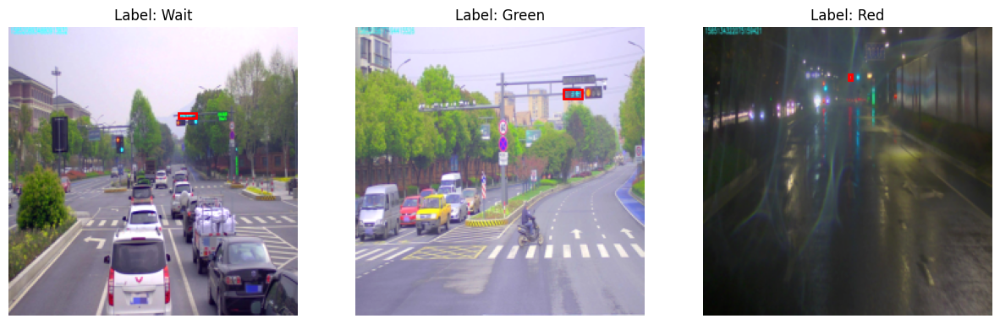

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch_samples(loader, n=3):
    # Get one batch
    images, labels, boxes = next(iter(loader))
    inv_label_map = {0: "Red", 1: "Green", 2: "Yellow", 3: "Off", 4: "Wait"}

    plt.figure(figsize=(15, 5))
    for i in range(n):
        # 1. Prepare image (un-normalize)
        img = images[i].numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        # 2. Convert normalized [cx, cy, w, h] back to pixel coordinates for display
        # Note: Loader resized images to 224x224
        cx, cy, w, h = boxes[i].numpy()
        xmin = (cx - w/2) * 224
        ymin = (cy - h/2) * 224
        xmax = (cx + w/2) * 224
        ymax = (cy + h/2) * 224

        # 3. Plot
        ax = plt.subplot(1, n, i + 1)
        plt.imshow(img)
        rect = plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, fill=False, color='red', linewidth=2)
        ax.add_patch(rect)
        plt.title(f"Label: {inv_label_map[labels[i].item()]}")
        plt.axis('off')
    plt.show()

show_batch_samples(train_loader)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F



class TrafficLightModel(nn.Module):
    def __init__(self, num_classes=5):
        super(TrafficLightModel, self).__init__()

        # --- Shared Backbone (5-Layer CNN) ---
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )

        # Flattened size for 224x224 input after 5 MaxPools (224 / 2^5 = 7)
        self.flatten_dim = 256 * 7 * 7

        # --- Head 1: Classification (Red, Green, Yellow, Off, Wait) ---
        self.class_head = nn.Sequential(
            nn.Linear(self.flatten_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes) # Output raw logits for CrossEntropy
        )

        # --- Head 2: Regression (Bounding Box [x, y, w, h]) ---
        self.bbox_head = nn.Sequential(
            nn.Linear(self.flatten_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 4),
            nn.Sigmoid() # Constrains output to [0, 1] as proposed
        )

    def forward(self, x):
        features = self.backbone(x)
        features = features.view(features.size(0), -1)

        class_out = self.class_head(features)
        bbox_out = self.bbox_head(features)

        return class_out, bbox_out

# Initialize and move to T4 GPU
model = TrafficLightModel().to(device)
print(model)

TrafficLightModel(
  (backbone): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (class_head): Sequential(
    (0): Linear(in_features=12544, out_fe

In [ ]:
# Giving higher importance to rare classes
# Weights roughly inverse to frequency: 1/count
weights = torch.tensor([1.0, 1.5, 5.0, 10.0, 3.0]).to(device)

criterion_class = nn.CrossEntropyLoss(weight=weights)
criterion_bbox = nn.SmoothL1Loss() # Robust to outliers

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import time

# 1. Define the Training Function
def train_model(model, train_loader, val_loader, optimizer, criterion_class, criterion_bbox, epochs=20):
    print(f"Starting Training on {device}...")

    for epoch in range(epochs):
        model.train()
        start_time = time.time()
        train_c_loss, train_b_loss = 0, 0

        for images, labels, boxes in train_loader:
            images, labels, boxes = images.to(device), labels.to(device), boxes.to(device)

            optimizer.zero_grad()
            class_out, bbox_out = model(images)

            # Multi-Task Loss Calculation
            loss_c = criterion_class(class_out, labels)
            loss_b = criterion_bbox(bbox_out, boxes)
            total_loss = loss_c + loss_b

            total_loss.backward()
            optimizer.step()

            train_c_loss += loss_c.item()
            train_b_loss += loss_b.item()

        # 2. Validation Step (Checking performance on unseen data)
        model.eval()
        val_c_loss = 0
        with torch.no_grad():
            for imgs, lbls, bxs in val_loader:
                imgs, lbls, bxs = imgs.to(device), lbls.to(device), bxs.to(device)
                c_out, _ = model(imgs)
                val_c_loss += criterion_class(c_out, lbls).item()

        # 3. Print Results for your Presentation logs
        avg_train = (train_c_loss + train_b_loss) / len(train_loader)
        avg_val = val_c_loss / len(val_loader)
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Time: {time.time()-start_time:.1f}s")

# Start the run
train_model(model, train_loader, val_loader, optimizer, criterion_class, criterion_bbox)

Starting Training on cuda...
Epoch [1/20] | Loss: 1.4074 | Val Loss: 1.4078 | Time: 33.3s
Epoch [2/20] | Loss: 1.2271 | Val Loss: 1.3853 | Time: 31.0s
Epoch [3/20] | Loss: 1.1222 | Val Loss: 1.2724 | Time: 32.8s
Epoch [4/20] | Loss: 1.0305 | Val Loss: 1.1415 | Time: 32.0s
Epoch [5/20] | Loss: 0.9102 | Val Loss: 1.0454 | Time: 30.6s
Epoch [6/20] | Loss: 0.7558 | Val Loss: 0.9103 | Time: 32.1s
Epoch [7/20] | Loss: 0.6703 | Val Loss: 0.8750 | Time: 31.4s
Epoch [8/20] | Loss: 0.5366 | Val Loss: 0.6192 | Time: 32.9s
Epoch [9/20] | Loss: 0.4885 | Val Loss: 0.5778 | Time: 32.0s
Epoch [10/20] | Loss: 0.3380 | Val Loss: 0.5894 | Time: 31.4s
Epoch [11/20] | Loss: 0.2863 | Val Loss: 0.5938 | Time: 31.8s
Epoch [12/20] | Loss: 0.2658 | Val Loss: 0.4948 | Time: 31.4s
Epoch [13/20] | Loss: 0.2158 | Val Loss: 0.6612 | Time: 32.2s
Epoch [14/20] | Loss: 0.2296 | Val Loss: 0.5250 | Time: 31.4s
Epoch [15/20] | Loss: 0.1673 | Val Loss: 0.7654 | Time: 31.8s
Epoch [16/20] | Loss: 0.1548 | Val Loss: 0.6235 | 

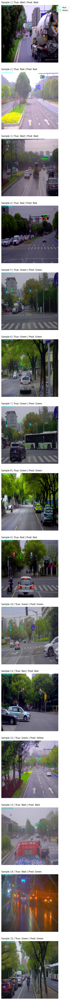

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np
import torch

def compare_boxes_vertical(model, test_dataset, num_samples=15):
    model.eval()
    inv_label_map = {0: "Red", 1: "Green", 2: "Yellow", 3: "Off", 4: "Wait"}

    # Adjusted figsize: Width=8, Height=5 per image (8 * 5 = 75 total height)
    # This ensures each image is large enough to see the thin border clearly
    plt.figure(figsize=(8, 5 * num_samples))

    for i in range(num_samples):
        # 1. Get real data
        img_tensor, label, bbox_true = test_dataset[i]

        # 2. Get model prediction on T4 GPU
        with torch.no_grad():
            class_out, bbox_out = model(img_tensor.unsqueeze(0).to(device))

        pred_label = torch.argmax(class_out, dim=1).item()
        pred_box = bbox_out.cpu().squeeze().numpy()
        true_box = bbox_true.numpy()

        # 3. Un-normalize image
        img = img_tensor.numpy().transpose((1, 2, 0))
        img = np.clip(np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406]), 0, 1)

        # CHANGE: subplot(rows, cols, index) -> num_samples rows, 1 column
        ax = plt.subplot(num_samples, 1, i + 1)
        plt.imshow(img)

        # --- Draw Real Box (Cyan Dashed) ---
        tcx, tcy, tw, th = true_box
        t_xmin, t_ymin = (tcx - tw/2) * 224, (tcy - th/2) * 224
        rect_true = plt.Rectangle((t_xmin, t_ymin), tw*224, th*224,
                                  fill=False, color='cyan', linestyle='--', linewidth=1.5, label='Real')
        ax.add_patch(rect_true)

        # --- Draw Model Box (Lime Solid) ---
        pcx, pcy, pw, ph = pred_box
        p_xmin, p_ymin = (pcx - pw/2) * 224, (pcy - ph/2) * 224
        rect_pred = plt.Rectangle((p_xmin, p_ymin), pw*224, ph*224,
                                  fill=False, color='lime', linewidth=1.5, label='Model')
        ax.add_patch(rect_pred)

        # Title to the right for better vertical layout readability
        plt.title(f"Sample {i+1} | True: {inv_label_map[label.item()]} | Pred: {inv_label_map[pred_label]}",
                  loc='left', fontsize=12, pad=10)

        plt.axis('off')
        if i == 0:
            plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

    plt.tight_layout(pad=3.0) # Increased padding to prevent overlap
    plt.show()

# Call the vertical comparison
compare_boxes_vertical(model, test_dataset, num_samples=15)



In [ ]:
model_v1 = model

In [ ]:
from tqdm.auto import tqdm

def train_with_tensorboard(model, train_loader, val_loader, optimizer, writer, epochs=15):
    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        running_loss_c = 0.0
        running_loss_b = 0.0
        correct = 0
        total = 0

        # Create a progress bar for the training batches
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", unit="batch")

        for i, (images, labels, boxes) in enumerate(train_bar):
            images, labels, boxes = images.to(device), labels.to(device), boxes.to(device)

            optimizer.zero_grad()
            c_out, b_out = model(images)

            loss_c = criterion_class(c_out, labels)
            loss_b = criterion_bbox(b_out, boxes)
            total_loss = loss_c + (10.0 * loss_b)

            total_loss.backward()
            optimizer.step()

            # Stats
            running_loss += total_loss.item()
            running_loss_c += loss_c.item()
            running_loss_b += loss_b.item()

            _, predicted = torch.max(c_out, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Update progress bar suffix with live loss
            train_bar.set_postfix(loss=f"{total_loss.item():.4f}", acc=f"{100 * correct / total:.1f}%")

            # TensorBoard logging
            global_step = epoch * len(train_loader) + i
            writer.add_scalar('Step/Loss_Total', total_loss.item(), global_step)

        # Log Epoch metrics
        train_acc = 100 * correct / total
        writer.add_scalar('Epoch/Loss_Total', running_loss / len(train_loader), epoch)
        writer.add_scalar('Epoch/Accuracy_Train', train_acc, epoch)

        # ===== Validation =====
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", unit="batch", leave=False)

        with torch.no_grad():
            for images, labels, boxes in val_bar:
                images, labels, boxes = images.to(device), labels.to(device), boxes.to(device)
                c_out, b_out = model(images)

                l_c = criterion_class(c_out, labels)
                l_b = criterion_bbox(b_out, boxes)
                loss = l_c + (10.0 * l_b)

                val_loss += loss.item()
                _, predicted = torch.max(c_out, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total
        writer.add_scalar('Epoch/Loss_Val', val_loss / len(val_loader), epoch)
        writer.add_scalar('Epoch/Accuracy_Val', val_acc, epoch)

        print(f"\n✨ Epoch {epoch+1} Summary: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

In [ ]:
# Initialize and Call
from torch.utils.tensorboard import SummaryWriter
model_v2 = TrafficLightModel().to(device)
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=0.001)
writer = SummaryWriter('logs/fit/Model_V2_tqdm_Final')

train_with_tensorboard(
    model=model_v2,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_v2,
    writer=writer,
    epochs=20
)

writer.close()

Epoch 1/20 [Train]:   0%|          | 0/31 [00:00<?, ?batch/s]

Epoch 1/20 [Val]:   0%|          | 0/4 [00:00<?, ?batch/s]


✨ Epoch 1 Summary: Train Acc: 31.73% | Val Acc: 39.34%


Epoch 2/20 [Train]:   0%|          | 0/31 [00:00<?, ?batch/s]

Epoch 2/20 [Val]:   0%|          | 0/4 [00:00<?, ?batch/s]

...

Epoch 19/20 [Val]:   0%|          | 0/4 [00:00<?, ?batch/s]


✨ Epoch 19 Summary: Train Acc: 92.73% | Val Acc: 77.05%


Epoch 20/20 [Train]:   0%|          | 0/31 [00:00<?, ?batch/s]

Epoch 20/20 [Val]:   0%|          | 0/4 [00:00<?, ?batch/s]


✨ Epoch 20 Summary: Train Acc: 94.47% | Val Acc: 79.51%


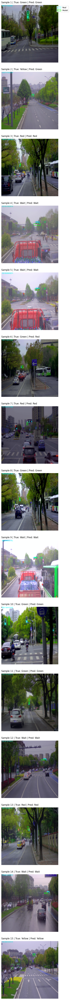

In [ ]:
compare_boxes_vertical(model_v2, train_dataset)